# Assignment 2: Transfer Learning Across Two Datasets

**Name:** Peyton Hoffman

**Prerequisite:** Transfer Learning lecture (frozen feature extraction)

This assignment uses frozen transfer learning, exactly what was covered in lecture: load a pretrained base, freeze it, add a new head, train only that. You'll do this twice, on two different datasets, and compare the results.

Data loading is provided for you below. Everything after that, building the model, training, evaluating, and reflecting, is yours to write, following the general instructions in each section.

**Submission:** GitHub repo URL and this notebook's URL on Canvas.

## Setup — Imports

In [36]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

---
# Part 1: Fire/Smoke Detection

## 1A — Load the Data

In [37]:
!pip install legacy-cgi --quiet
!pip install opendatasets --quiet

import opendatasets as od
od.download("https://www.kaggle.com/datasets/phylake1337/fire-dataset")

for root, dirs, files in os.walk("fire-dataset"):
    print(root, "->", dirs[:5], f"({len(files)} files)")

Skipping, found downloaded files in "./fire-dataset" (use force=True to force download)
fire-dataset -> ['fire_dataset'] (0 files)
fire-dataset/fire_dataset -> ['fire_images', 'non_fire_images'] (0 files)
fire-dataset/fire_dataset/fire_images -> [] (755 files)
fire-dataset/fire_dataset/non_fire_images -> [] (244 files)


In [38]:
data_dir_fire = "fire-dataset/fire_dataset"

img_size = (224, 224)
batch_size = 32

train_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_fire = tf.data.experimental.cardinality(val_test_raw_fire)
test_raw_fire = val_test_raw_fire.take(val_test_batches_fire // 2)
val_raw_fire = val_test_raw_fire.skip(val_test_batches_fire // 2)

class_names_fire = train_raw_fire.class_names
print("Class names:", class_names_fire)

Found 999 files belonging to 2 classes.
Using 700 files for training.
Found 999 files belonging to 2 classes.
Using 299 files for validation.
Class names: ['fire_images', 'non_fire_images']


## 1B — Inspect the Data

Before doing anything else, take a real look at what you loaded. How many images does each class have? Is there anything about the data itself that might affect how you should split it, or how you should interpret your model's results later?

Write whatever code you need to answer this for yourself.

In [39]:
# Your exploration here

for class_name in class_names_fire:
    folder = os.path.join(data_dir_fire, class_name)
    print(class_name, ":", len(os.listdir(folder)), "images")

fire_images : 755 images
non_fire_images : 244 images


*What did you notice about this dataset? Does it change how you'll approach the next steps?*

There are 755 fire images and 244 non-fire images, so the dataset is unbalanced. Each split should have a similar mix of both classes. I should check the confusion matrix because high accuracy could hide mistakes on non-fire images.

## 1C — Build a Frozen Transfer Learning Model

Using MobileNetV2 as your pretrained base:
- Freeze the base model entirely
- Add a new output layer appropriate for this task (think about how many classes you're predicting, and what that means for your output layer's size, activation, and loss function)
- Remember the pattern from lecture for how the base model should be called

Preprocess your data (`train_raw_fire`, `val_raw_fire`, `test_raw_fire`) using MobileNetV2's expected preprocessing before building your model.

In [40]:
# Preprocess the data here

def preprocess_mobilenet(images, labels):
    return preprocess_input(images), labels

train_fire = train_raw_fire.map(preprocess_mobilenet)
val_fire = val_raw_fire.map(preprocess_mobilenet)
test_fire = test_raw_fire.map(preprocess_mobilenet)

In [41]:
# Build your model here

base_fire = MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)

base_fire.trainable = False

x = base_fire.output
x = GlobalAveragePooling2D()(x)
output = Dense(1, activation='sigmoid')(x)

model_fire = Model(inputs=base_fire.input, outputs=output)

In [43]:
# Compile your model here

model_fire.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## 1D — Train and Evaluate

In [44]:
# Train your model here

history_fire = model_fire.fit(
    train_fire,
    validation_data=val_fire,
    epochs=5
)

Epoch 1/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 98s 4s/step - accuracy: 0.7829 - loss: 0.3960 - val_accuracy: 0.9209 - val_loss: 0.2363
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 66s 3s/step - accuracy: 0.9629 - loss: 0.1634 - val_accuracy: 0.9568 - val_loss: 0.1543
Epoch 3/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 57s 3s/step - accuracy: 0.9686 - loss: 0.1129 - val_accuracy: 0.9640 - val_loss: 0.1014
Epoch 4/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 59s 3s/step - accuracy: 0.9786 - loss: 0.0916 - val_accuracy: 0.9784 - val_loss: 0.0842
Epoch 5/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 62s 3s/step - accuracy: 0.9829 - loss: 0.0785 - val_accuracy: 0.9784 - val_loss: 0.0779


In [45]:
# Report validation and test accuracy here

val_loss, val_accuracy = model_fire.evaluate(val_fire)
test_loss, test_accuracy = model_fire.evaluate(test_fire)

print("Fire Validation Accuracy:", val_accuracy)
print("Fire Test Accuracy:", test_accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.9640 - loss: 0.0953
5/5 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.9688 - loss: 0.0967
Fire Validation Accuracy: 0.9640287756919861
Fire Test Accuracy: 0.96875


## 1E — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** In this context, is a false negative (missing a real fire) or a false positive (a false alarm) more costly? How might that change the decision threshold you'd actually use in practice, rather than the default 0.5?

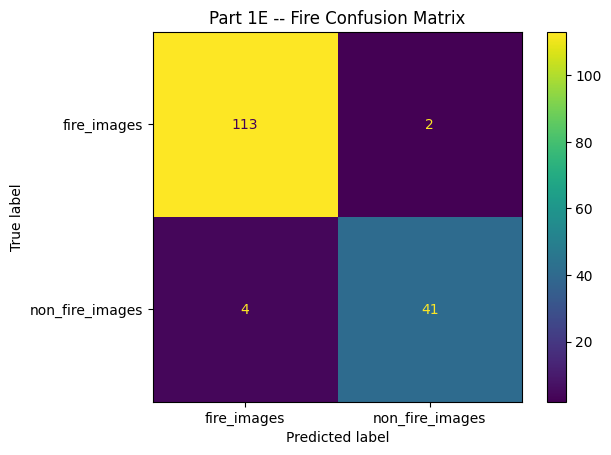

In [46]:
# Build your confusion matrix here

actual_labels = []
final_preds = []

for images, labels in test_fire:
    final_probs = model_fire.predict(images, verbose=0)
    predictions = (final_probs.ravel() >= 0.5).astype(int)

    actual_labels.extend(labels.numpy())
    final_preds.extend(predictions)

# Create the confusion matrix
final_cm = confusion_matrix(actual_labels, final_preds)

ConfusionMatrixDisplay(
    final_cm,
    display_labels=class_names_fire
).plot()

plt.title("Part 1E -- Fire Confusion Matrix")
plt.show()

A false negative is more costly because missing a real fire could put people in danger. My model missed 2 fires and produced 4 false alarms. I would consider raising the non-fire cutoff above 0.5 to catch more fires, even if it causes more false alarms.

---
# Part 2: Satellite Land-Use Classification (EuroSAT)

## 2A — Load the Data

In [47]:
!wget -q "https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1" -O EuroSAT_RGB.zip
!unzip -q EuroSAT_RGB.zip -d eurosat_data

data_dir_sat = "eurosat_data/EuroSAT_RGB"
print(os.listdir(data_dir_sat))

replace eurosat_data/EuroSAT_RGB/Forest/Forest_864.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
['PermanentCrop', 'Highway', 'Industrial', 'River', 'AnnualCrop', 'Pasture', 'HerbaceousVegetation', 'Residential', 'Forest', 'SeaLake']


In [48]:
train_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_sat = tf.data.experimental.cardinality(val_test_raw_sat)
test_raw_sat = val_test_raw_sat.take(val_test_batches_sat // 2)
val_raw_sat = val_test_raw_sat.skip(val_test_batches_sat // 2)

class_names_sat = train_raw_sat.class_names
print("Class names:", class_names_sat)

Found 27000 files belonging to 10 classes.
Using 18900 files for training.
Found 27000 files belonging to 10 classes.
Using 8100 files for validation.
Class names: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## 2B — Build a Frozen Transfer Learning Model

Same overall pattern as Part 1, but look closely at what's different about this task before you build your output layer, activation, and loss function.

Preprocess `train_raw_sat`, `val_raw_sat`, and `test_raw_sat` first.

In [49]:
# Preprocess the data here

def preprocess_mobilenet(image, label):
    return preprocess_input(image), label

train_sat = train_raw_sat.map(preprocess_mobilenet)
val_sat = val_raw_sat.map(preprocess_mobilenet)
test_sat = test_raw_sat.map(preprocess_mobilenet)

In [50]:
# Build your model here

base_sat = MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)

base_sat.trainable = False

x = base_sat.output
x = GlobalAveragePooling2D()(x)
output = Dense(len(class_names_sat), activation='softmax')(x)

model_sat = Model(inputs=base_sat.input, outputs=output)

In [51]:
# Compile your model here

model_sat.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


## 2C — Train and Evaluate

In [52]:
# Train your model here

history_sat = model_sat.fit(
    train_sat,
    validation_data=val_sat,
    epochs=5
)

Epoch 1/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 1173s 2s/step - accuracy: 0.8761 - loss: 0.3745 - val_accuracy: 0.9304 - val_loss: 0.2168
Epoch 2/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 1137s 2s/step - accuracy: 0.9340 - loss: 0.1964 - val_accuracy: 0.9398 - val_loss: 0.1917
Epoch 3/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 1111s 2s/step - accuracy: 0.9465 - loss: 0.1606 - val_accuracy: 0.9405 - val_loss: 0.1860
Epoch 4/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 1083s 2s/step - accuracy: 0.9528 - loss: 0.1389 - val_accuracy: 0.9388 - val_loss: 0.1822
Epoch 5/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 1105s 2s/step - accuracy: 0.9603 - loss: 0.1221 - val_accuracy: 0.9430 - val_loss: 0.1772


In [53]:
# Report validation and test accuracy here

val_loss_sat, val_accuracy_sat = model_sat.evaluate(val_sat)
test_loss_sat, test_accuracy_sat = model_sat.evaluate(test_sat)

print("Satellite Validation Accuracy:", val_accuracy_sat)
print("Satellite Test Accuracy:", test_accuracy_sat)

127/127 ━━━━━━━━━━━━━━━━━━━━ 190s 1s/step - accuracy: 0.9418 - loss: 0.1816
127/127 ━━━━━━━━━━━━━━━━━━━━ 187s 1s/step - accuracy: 0.9373 - loss: 0.1790
Satellite Validation Accuracy: 0.9417740106582642
Satellite Test Accuracy: 0.9372539520263672


## 2D — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** Which land-use classes get confused most often? Does that make visual sense to you?

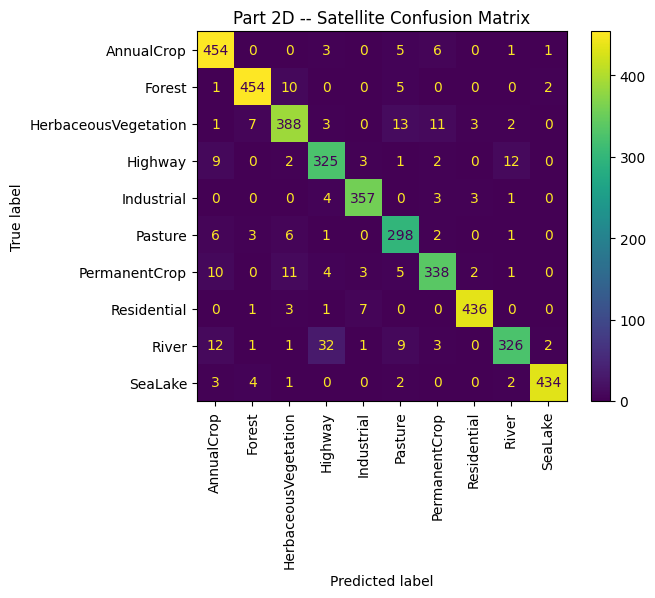

In [54]:
# Build your confusion matrix here

actual_labels_sat = []
final_preds_sat = []

for images, labels in test_sat:
    final_probs_sat = model_sat.predict(images, verbose=0)
    predictions = np.argmax(final_probs_sat, axis=1)

    actual_labels_sat.extend(labels.numpy())
    final_preds_sat.extend(predictions)

# Create the confusion matrix
final_cm_sat = confusion_matrix(actual_labels_sat, final_preds_sat)

ConfusionMatrixDisplay(
    final_cm_sat,
    display_labels=class_names_sat
).plot(xticks_rotation=90)

plt.title("Part 2D -- Satellite Confusion Matrix")
plt.show()

The model confused River and Highway most often: 32 river images were predicted as highways, and 12 highway images were predicted as rivers. This makes sense because both can look like long, narrow paths from above.

---
# Part 3: Compare the Two Domains

Fill in your own results:

| | Fire/Smoke | EuroSAT |
|---|---|---|
| Validation Accuracy |0.964|0.942|
| Test Accuracy |0.969|0.937|

**Answer:**
1. MobileNetV2 was originally trained on ImageNet, ordinary ground-level photos of everyday objects. Which of your two datasets do you think is the closer match to that original training, and which is the bigger mismatch? Use your actual results as evidence.
2. For each dataset, do you think there's room for improvement if you could adjust part of the pretrained model itself, rather than just the new layer on top? Would you expect that to matter more for one dataset than the other? Why?

1. The fire dataset is a closer match to ImageNet because it uses ground level photos. EuroSAT is a bigger mismatch because its pictures are taken from above and has a larger dataset. My fire test accuracy was 96.9%, and EuroSAT was 93.7%.

2. I think adjusting some pretrained layers could improve both models by helping them learn patterns specific to each dataset. I would expect this to help EuroSAT more because satellite images look much more different from ImageNet photos.

---
# Part 4: Reflection

Answer in 4 to 6 sentences:

1. Did anything about the Fire dataset's composition affect how you approached splitting or evaluating it? Explain.
2. What's the actual difference between the output layer, activation, and loss function you used in Part 1 versus Part 2? Why does that difference exist?
3. Based on your results, does a pretrained model's usefulness depend only on how good the model is, or also on how well its original training matches your task? Explain using your own two results as evidence.

The fire dataset had more fire images than non-fire images, so I used the confusion matrix to check how well the model recognized both. For fire detection, I used one output with sigmoid and binary cross-entropy because there were two classes. For EuroSAT, I used ten outputs with softmax and sparse categorical cross-entropy because there were ten classes with number labels. A pretrained models usefulness depends on both how good it is and how similar its original training images are to the new images. My fire model got 96.9% test accuracy, compared with 93.7% for EuroSAT, which may be because fire photos are more similar to ImageNet photos, although EuroSAT also had more classes to predict.

---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.